# 4. Calibration of the HBV model

## 4.1 Model selection

The HBV model will be selected to simulate discharge in the Lower Athabasca River. HBV is a rainfall runoff model representing hydrological processes requiring limited parameter input and storage components. This makes the model computationally efficient which is useful for calibration. See Table 4.1 for a list of the input parameters. 

HBV has the ability to represent snow accumulation and snowmelt with its snowmelt parameter. This is important for the LAR, where snow processes heavily influence discharge. The basin contains both high elevation mountains in the Rockies and lower plains downstream resulting in a spatial variability, which HBV can account for.

This model also has limitations. The HBV model does not explicitly include a glacier melt parameter. A HBV adaptation such as HBV-EC could be more suitable, which is not provided by eWaterCycle. However, this contribution is small at the LAR and therefore expected to cause minor conceptual errors. In addition, this model does not explicitly represent non-contributing areas such as potholes that occur in the boreal basin. 


*Table 4.1: HBV model parameters.*

| **Parameter**            | **Description**                                          |
|--------------------------|----------------------------------------------------------|
| $I_{\text{max}}$         | Maximum interception storage [mm]                        |
| $C_{\text{e}}$           | Evaporation correction factor [-]                        |
| $S_{\text{u,max}}$       | Maximum soil moisture storage [mm]                       |
| $\beta$                  | Soil runoff parameter [-]                                |
| $P_{\text{max}}$         | Maximum percolation rate [mm/day]                        |
| $T_{\text{lag}}$         | Time lag [days]                                          |
| $K_{\text{f}}$           | Fast reservoir recession coeofficient     [1/day]        |
| $K_{\text{s}}$           | Slow reservoir recession coeofficient     [1/day]        |
| $F_{\text{M}}$           | Snowmelt factor                           [-]            |

A visual representation of the model, parameters and storages can be seen in Figure 8 below:

<figure>
  <img src="Figures/HBV_Visualisation.jpg">
  <figcaption><b>Figure 8:</b> Visualisation of the HBV model parameters and storages (Hrachowitz, n.d.).</figcaption>
</figure>

## 4.2 Calibration methodology

The HBV model is calibrated using observed daily discharge data from station 07DA001 at Fort McMurray and ERA5 climate data. ERA5 provides 2 m above surface temperature, precipitation, shortwave radiation and calculates potential evaporation. The available discharge data is divided into a calibration and validation period using an 80/20 split, respectively. The calibration period runs from 1999-2019 and the validation period from 2019-2024. For both calibration and validation, the first year will act as a warm up period allowing model storages to fill up.

The HBV model is run multiple times using various parameter sets. Each parameter set is randomly sampled from parameter ranges manually determined based on previous runs. For every run, the used parameter set is evaluated based on differences between modelled and observed data using statistical analysis,  LNSE (See 4.3). The model will be run 1000 times for calibration. As a result, 1000 different sets of parameters are rated and ranked based on model performance. Instead of selecting one optimal parameter set, the 5 best parameter sets will be returned, creating an ensemble of best sets. The selected ensemble will be applied to the validation period and later to future climate forcing, producing a range and mean estimate of future discharge and low flow days. This ensemble approach gives an estimate of model uncertainty and improves reproducibility of the calibration results, as the influence of errors in one parameter set are reduced by averaging. Furthermore, various parameter sets might have varying strengths in modelling accuracy (e.g. identifying low flow between peaks or identifying transition timing between long high and low flow periods). For a list and interpretation of calibrated parameter values for each set, see Appendix B. 

Winter months from December to April are excluded from evaluating parameter set performance during calibration. This is because low winter baseflow is not the focus of this study and will significantly dilute calibration results. 


## 4.3 Logarithmic Nash-Sutcliff Efficiency

The logarithmic Nash-Sutcliffe Efficiency (LNSE) is a commonly used metric to evaluate how well modelled discharge coincides with observed discharge (Duc & Sawada, 2023). It originates from the NSE method, which compares the variance of the modelled prediction errors to the variance in observed data. NSE is strongly influenced by high flow peaks where errors are squared. By applying a logarithmic transformation to both discharge and modelled data, errors during low flow are relatively weighed more heavily. This makes LNSE a suitable method for this research. 

The logarithmic Nash-Sutcliffe Efficiency is calculated as:

$log NSE = 1 - \frac{\Sigma(logQ_{obs}-logQ_{sim})^2}{\Sigma(logQ_{obs} - \overline{logQ_{obs}})^2}$

Where $Q_{obs}$ is the observed discharge at one time step, $Q_{sim}$ the simulated discharge at one time step and $\overline{logQ_{sim}}$the mean of the log observed discharge. The output result may range from -∞ to 1, where 1 indicates a perfect model fit (HEC-HMS, n.d.). 

In [ ]:
LNSE will be calculated using the following functions:

In [ ]:
# Calculate log NSE

def LNSE(sim, obs):
    
    sim = sim.to_numpy()
    obs = obs.to_numpy()

    # Avoid log(0)
    eps = 0.00000000001

    log_sim = np.log(sim + eps)
    log_obs = np.log(obs + eps)

    return 1 - np.sum((log_obs - log_sim) ** 2) / np.sum((log_obs - np.mean(log_obs)) ** 2)

In [ ]:
# Call log NSE for relevant timeperiod

def lnse_ensemble(ensemble_data, lnse_start, lnse_end):

    # Select evaluation period - skip first year for storages to fill
    combined_data = ensemble_data[
        (ensemble_data.index >= lnse_start) &
        (ensemble_data.index <= lnse_end)].dropna()

    # Exclude winter months
    combined_data = combined_data[
        ~combined_data.index.month.isin([12, 1, 2, 3, 4])]

    lnse_results = []

    # Calculate LNSE for all sets
    for i in range(len(par_ensemble)):
        lnse_value = LNSE(
            combined_data[f"Set {i+1}"],
            combined_data["Observed discharge"])

        # Append LNSE
        lnse_results.append({
            "Set": f"Set {i+1}",
            "LNSE": lnse_value})

    # Calculate LNSE of ensemble mean
    mean_lnse = LNSE(
        combined_data["Mean"],
        combined_data["Observed discharge"])

    # Append LNSE
    lnse_results.append({
        "Set": "Ensemble mean",
        "LNSE": mean_lnse})

    lnse_results = pd.DataFrame(lnse_results)

    return lnse_results

## 4.4 Calibration results

As mentioned before, the HBV model was calibrated from 1999-2019 excluding the first year as a warm up period and 5 winter months. Figure 9 shows the observed and modelled data over this period. Overall, the model reproduces the discharge reasonably well. The 5 best parameter sets returned an LNSE ranging from 0,64 to 0,72 with a 0,68 median. The mean discharge from the sets returns an improved LNSE of 0,74, which can be considered a good model fit. Most high flow peaks are not modelled accurately, which is acceptable within the scope of the study. Low flow periods and the transition from high to low discharge periods are generally represented well which is important for identifying critical low flow days. The code used for the calibration can be seen in Appendix C. The code for generating ERA5 & CMIP6 data can be seen in Appendix F & G.

In [42]:
# General python
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# Niceties
from rich import print

In [43]:
# General eWaterCycle
import ewatercycle
import ewatercycle.models
import ewatercycle.forcing

In [44]:
# Defining things

basin_size = 132572
q_critical = 500

# Choosing time period

validation_start_yr = 1999
validation_end_yr = 2019

experiment_start_date = f"{validation_start_yr}-01-01T00:00:00Z"
experiment_end_date = f"{validation_end_yr}-12-31T00:00:00Z"

validation_start = f"{validation_start_yr}-01-01T00:00:00Z"
validation_end = f"{validation_end_yr}-12-31T00:00:00Z"

In [45]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "forcings" / "ERA5" / f"ERA5-{validation_start_yr}-{validation_end_yr}"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [46]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [47]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs to relevant dates
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

In [69]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

In [70]:
# Load calibration constants

par_ensemble = [
    [6.279135, 0.4808243, 174.127749, 1.9527195, 0.3305087, 6.19919, 0.0768362, 0.004366398, 0.4076606],
    [7.35776, 0.432509, 192.67085, 1.66088, 0.289296, 5.323766, 0.037268, 0.004399, 1.146504],
    [7.9355, 0.4593, 219.6962, 1.72624, 0.26391, 5.810765, 0.04804, 0.0155065, 0.76857],
    [5.5464, 0.46496, 187.8548, 1.82803, 0.440628, 6.29496, 0.062766, 0.033095, 0.80392],
   [7.23868, 0.47495, 181.82012, 1.8232, 0.4884032, 5.546412, 0.0449439, 0.00231717, 1.25052]]


par_names = ["Imax",         # Maximum interception storage
               "Ce",         # Evaporation correction factor
               "Sumax",      # Maximum soil moisture storage
               "Beta",       # Soil runoff parameter
               "Pmax",       # Maximum percolation rate
               "Tlag",       # Time lag
               "Kf",         # Fast reservoir recession coefficient
               "Ks",         # Slow reservoir recession coefficient
               "FM"]          # Snowmelt factor

In [50]:
# Storages

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

In [65]:
# Model setup

def run_hbv(parameters, initial_storages, forcing):

    # Creating model object
    model = ewatercycle.models.HBV(forcing=forcing)

    # Creating config file
    config_file, _ = model.setup(
        parameters=parameters,
        initial_storages=initial_storages,
        cfg_dir=hbv_config)

    # Initialising model
    model.initialize(config_file)

    # Define & update outputs
    Q_m = []
    time = []

    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Convert mm/day to m3/s
    model_output_mmday = pd.Series(
        data=Q_m,
        index=time,
        name="Modelled discharge")

    model_output_m3s = model_output_mmday * basin_size * 1000 / 86400

    return model_output_m3s

In [66]:
# Running model

def run_hbv_ensemble(par_ensemble, initial_storages, forcing):

    # Define amount of parameter sets
    N = len(par_ensemble)
    
    # Create dataframe to append data to & add column for observed data
    ensemble_data = pd.DataFrame()

    for i in range(N):

        print(f"Running parameter set {i+1}/{N}")

        # Run HBV model for the parameter sets 
        simulated = run_hbv(
            parameters=par_ensemble[i],
            initial_storages=initial_storages,
            forcing=forcing)

        # Filter data by day only, not by day & time to prevent alignment issues
        simulated_daily = simulated

        simulated_daily.index = pd.to_datetime(simulated_daily.index).tz_localize(None).normalize()
        simulated_daily.name = f"Set {i+1}"
         
        # Append new column for every parameter set results
        ensemble_data[f"Set {i+1}"] = simulated

    # Filter observed data by day
    observed_daily = observed_output
    observed_daily.index = pd.to_datetime(observed_daily.index).tz_localize(None).normalize()

    # Add mean of all sets
    ensemble_data["Mean"] = ensemble_data.mean(axis=1)
    ensemble_data['Observed discharge'] = observed_daily

    return ensemble_data

In [53]:
ensemble_data = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing)

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

In [67]:
# Plotting function

def plot_ensemble(ensemble_data, plot_start, plot_end):

    plot_start = pd.to_datetime(plot_start)
    plot_end = pd.to_datetime(plot_end)

    # Filter data to start & end time
    plot_data = ensemble_data[
        (ensemble_data.index >= plot_start) &
        (ensemble_data.index <= plot_end)].dropna()

    # Define figure
    plt.figure()
    plt.figure(figsize=(15, 6))

    # Plot sets, observed data, ensemble mean and axhline, respectively
    for i in range(len(par_ensemble)):
        plt.plot(plot_data.index, plot_data[f"Set {i+1}"], color="orange", alpha=0.3, label="Parameter sets" if i == 0 else None)

    plt.plot(plot_data.index, plot_data["Observed discharge"], label="Observed discharge", linewidth=3)
    plt.plot(plot_data.index, plot_data["Mean"], label="Ensemble mean", linewidth=3)
    plt.axhline(y=q_critical, linestyle=":", color="black", label=f"Critical discharge ({q_critical} m³/s)")

    # Extras
    plt.xlabel("Date")
    plt.ylabel("Discharge (m³/s)")
    plt.title("Observed vs modelled ensemble discharge at 07DA001")
    plt.legend()
    plt.grid(True)

    plt.show()

<Figure size 640x480 with 0 Axes>

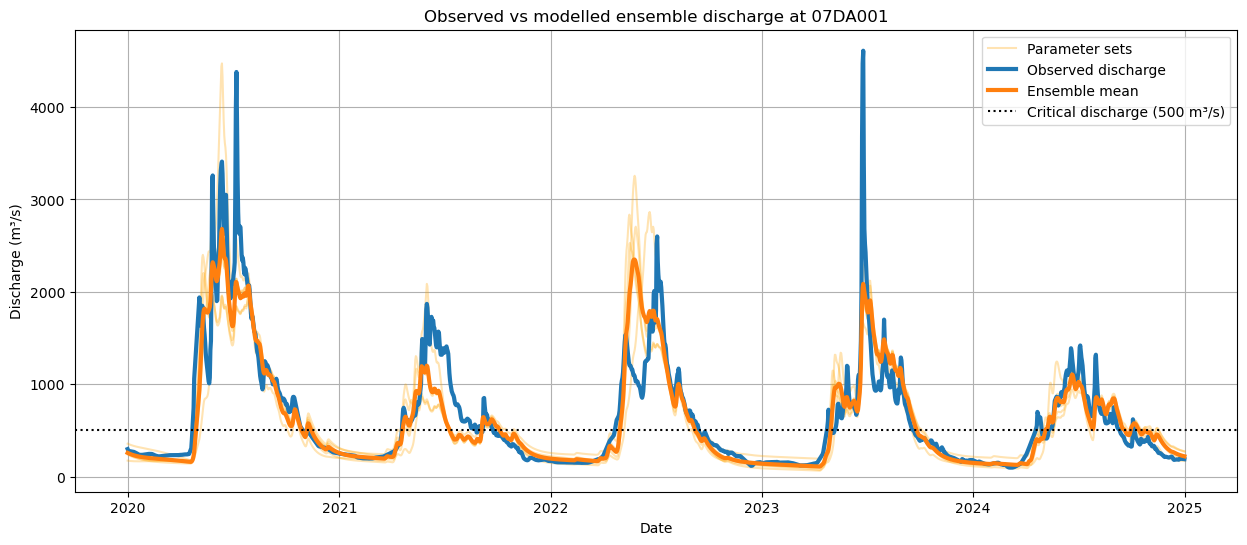

In [68]:
# Plot for full evaluation period

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=evaluation_start,
    plot_end=validation_end_date)

**Figure 9:** Modelled vs observed discharge over the calibration period.

## 4.5 Validation results

The 5 best parameter sets were applied to the validation period 2019-2024, excluding the first year as a warm up period. Figure 10 shows the observed and modelled discharge over this period. The parameter sets returned an LNSE ranging from 0,72 to 0,77 with a 0,74 median. The model mean has an improved LNSE of 0,81,  which suggests a very good model performance. Interestingly, this shows an improvement from the calibration period which may suggest the parameter set’s performance is consistent which is important when modelling discharge in the far future. For yearly graphs, see Appendix D. 

In [56]:
# Choosing new time period

validation_start_yr = 2019
validation_end_yr = 2024

experiment_start_date = f"{validation_start_yr}-01-01T00:00:00Z"
experiment_end_date = f"{validation_end_yr}-12-31T00:00:00Z"

validation_start = f"{validation_start_yr}-01-01T00:00:00Z"
validation_end = f"{validation_end_yr}-12-31T00:00:00Z"

In [57]:
# Create pathways for ERA 5 forcings

forcing_path_ERA5 = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "forcings" / "ERA5" / f"ERA5-{validation_start_yr}-{validation_end_yr}"

discharge_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "07DA001_discharge_daily_withoutmissing.csv"

shape_file = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "Shapefiles" / "07DA001_basin.shp"

hbv_config = Path.home() / "BEP-maxime" / "book" / "thesis_projects" / "BSc" / "2026_Q4_MaximedeBekker_CEG" /  "Workyard" / "hbv_config"
hbv_config.mkdir(parents=True, exist_ok=True)

In [58]:
# Load CSV discharge 07DA001

q_obs = pd.read_csv(discharge_file, skiprows=1)
q_obs = q_obs[["Date", "Value"]].copy()
q_obs["Date"] = pd.to_datetime(q_obs["Date"])
q_obs = q_obs.rename(columns={"Value": "discharge_m3s"})

In [59]:
# Define time period
validation_start_date = pd.to_datetime(validation_start.replace("Z", ""))
validation_end_date = pd.to_datetime(validation_end.replace("Z", ""))

# Skip 1 year for filling storages
evaluation_start = pd.to_datetime(f"{validation_start_date.year + 1}-01-01")

# Align q_obs to relevant dates
q_obs = q_obs[(q_obs["Date"] >= validation_start_date) & (q_obs["Date"] <= validation_end_date)]
observed_output = pd.Series(data=q_obs["discharge_m3s"].to_numpy(), name="Observed discharge", index=q_obs["Date"])

In [71]:
# Generate ERA5 data
# ERA5_forcing = ewatercycle.forcing.sources['LumpedMakkinkForcing'].generate(
#     dataset="ERA5",
#     start_time=experiment_start_date,
#     end_time=experiment_end_date,
#     shape=shape_file,
# )

# Load data

ERA5_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=forcing_path_ERA5)

In [61]:
ensemble_data = run_hbv_ensemble(
    par_ensemble=par_ensemble,
    initial_storages=s_0,
    forcing=ERA5_forcing)

Running parameter set 1/5

Running parameter set 2/5

Running parameter set 3/5

Running parameter set 4/5

Running parameter set 5/5

<Figure size 640x480 with 0 Axes>

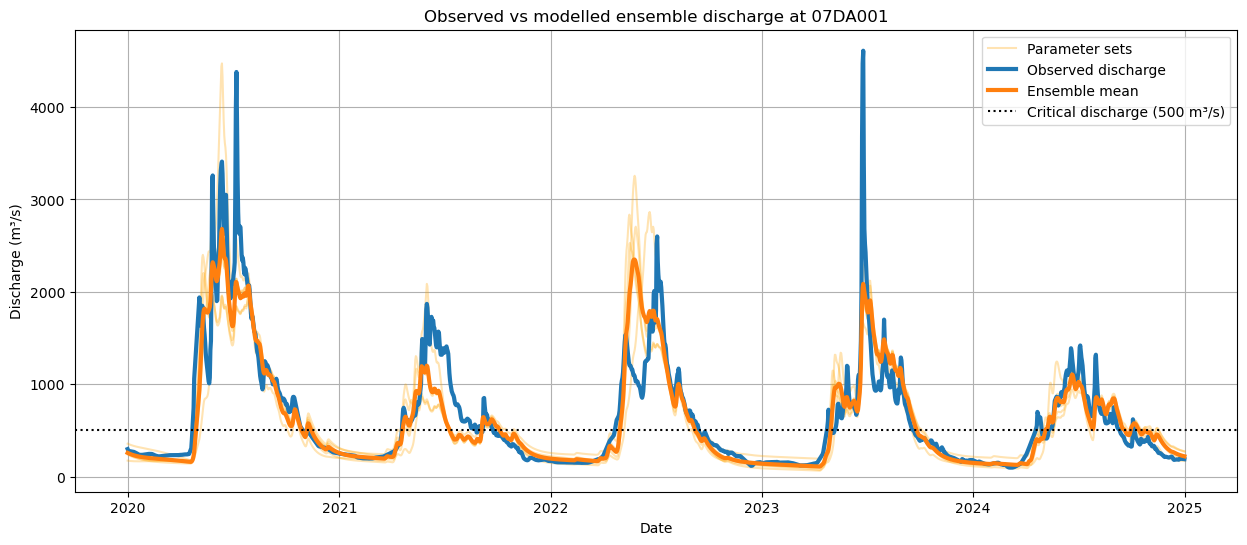

In [62]:
# Plot for full evaluation period

plot_ensemble(
    ensemble_data=ensemble_data,
    plot_start=evaluation_start,
    plot_end=validation_end_date)

**Figure 10:** Observed vs modelled discharge for the validation period. 

Although low flow periods are reproduced reasonably accurately visually, when comparing low flow days between observed and modelled data, the model varies significantly in accuracy. In years such as 2020 and 2022, the difference is almost zero. In other years such as 2021 and 2024, errors exceed almost 100%. 

An explanation could be that fluctuations close to Qcritical may significantly influence results as can be seen in both 2021 and 2024. Even though observed discharge may be slightly above Qcritical, navigation may still be restricted on 7 critical sites rather than 8. An inflation of modelled low flow days may therefore not be problematic in answering the research question if this is the nature of the errors. Furthermore, errors could occur due to conceptual modelling errors (potholes and glacial melt exclusion). 

*Table 4.2: Observed and modelled low flow days for validation period.*

| **Year**  | **Observed lowflow days** | **Mean modelled lowflow days** |
|-----------|---------------------------|--------------------------------|
| 2020      | 0                         | 0                              |
| 2021      | 30                        | 67                             | 
| 2022      | 34                        | 40                             |
| 2023      | 27                        | 22                             | 
|2024       | 34                        | 14                             |

The function used to generate the data used to manually create this table can be seen in the cell below:

In [63]:
def lowflow_counter_ensemble(ensemble_data, start_date, end_date):
    
    lowflow_days = []

    years = list(range(start_date.year, end_date.year + 1))

    for i in range(len(years)):
    
        year = years[i]
    
        # Define start and end month-day
        year_start = pd.to_datetime(f"{year}-05-18")
        year_end = pd.to_datetime(f"{year}-10-17")
    
        year_data = ensemble_data[
            (ensemble_data.index >= year_start) &
            (ensemble_data.index <= year_end)]

        # Set zeros to count from
        observed_lowflow_days = 0
        modelled_lowflow_days = []
        modelmean_lowflow_days = 0

        # Count observed lowflow days
        for j in range(len(year_data)):

            observed_q = year_data.iloc[j]["Observed discharge"]

            if observed_q < q_critical:
                observed_lowflow_days += 1

        # Count model mean lowflow days
        for j in range(len(year_data)):

            modelmean_q = year_data.iloc[j]["Mean"]

            if modelmean_q < q_critical:
                modelmean_lowflow_days += 1

        # Count modelled lowflow days
        for j in range(len(par_ensemble)):

            set_lowflow_days = 0

            for k in range(len(year_data)):

                set_q = year_data.iloc[k][f"Set {j+1}"]

                if set_q < q_critical:
                    set_lowflow_days += 1

            modelled_lowflow_days.append(set_lowflow_days)

        setavg_lowflow_days = np.mean(modelled_lowflow_days)
        
        lowflow_days.append({
            "year": year,
            "observed": observed_lowflow_days,
            "modelmean": modelmean_lowflow_days,
            "set_1": modelled_lowflow_days[0],
            "set_2": modelled_lowflow_days[1],
            "set_3": modelled_lowflow_days[2],
            "set_4": modelled_lowflow_days[3],
            "set_5": modelled_lowflow_days[4],
            "set_avg": np.round(setavg_lowflow_days)})

    lowflow_days = pd.DataFrame(lowflow_days)

    return lowflow_days

In [64]:
lowflow_counter_ensemble(
    ensemble_data=ensemble_data,
    start_date=evaluation_start,
    end_date=validation_end_date)

,year,observed,modelmean,set_1,set_2,set_3,set_4,set_5,set_avg
0,2020,0,0,9,0,0,0,0,2.0
1,2021,30,67,71,68,70,68,53,66.0
2,2022,34,40,47,35,39,42,32,39.0
3,2023,27,22,31,15,21,23,12,20.0
4,2024,34,14,38,13,14,11,1,15.0
